# Statistical Evaluation of Language Models

This notebook implements the experiment described in my seminar paper. The goal of the experiment is to evaluate and compare two language models using statistical evaluation methods.

The models used in this experiment are:

• GPT-2  
• DistilGPT2  

DistilGPT2 is a compressed (distilled) version of GPT-2. Model distillation is used to create a smaller and faster model while trying to retain similar performance to the original model.

The main research question of this experiment is:

"Can a smaller distilled model achieve performance comparable to the original larger model?"

To investigate this question, both models are tested on a dataset of factual questions. Their performance is evaluated using several statistical metrics, including accuracy, variance, standard deviation, confidence intervals, and hypothesis testing.

Using multiple statistical measures helps provide a more reliable comparison between the models instead of relying only on a single accuracy value.

In [ ]:
# Installing required libraries

# transformers → used to load pretrained language models
# torch → backend used by HuggingFace models
# numpy → numerical calculations
# matplotlib / seaborn → visualization of results
# scipy → statistical testing

!pip install transformers
!pip install torch
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scipy

## Importing Required Libraries

In this section we import the Python libraries that will be used throughout the experiment.

The transformers library provides access to pretrained language models from HuggingFace.  
NumPy is used for numerical operations such as computing averages.  
Matplotlib and seaborn are used to create graphs for visualizing the results.  
SciPy provides statistical testing functions which will be used to compare the models.

In [ ]:
from transformers import pipeline
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

## Loading the Language Models

Two language models are loaded using the HuggingFace transformers library.

1. GPT-2  
   This is the original model released by OpenAI. It is trained on a large corpus of internet text and is capable of generating coherent text continuations.

2. DistilGPT2  
   This is a smaller version of GPT-2 created using a technique called knowledge distillation.  
   The goal of distillation is to create a model that is faster and more efficient while retaining most of the performance of the larger model.

The experiment will compare how these two models perform when answering factual questions.

In [ ]:
gpt2 = pipeline("text-generation", model="gpt2")
distil = pipeline("text-generation", model="distilgpt2")

print("Both models were loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Both models were loaded successfully.


## Dataset Description

For this experiment a dataset of 50 factual questions was created.  
The questions cover topics such as:

• geography  
• history  
• science  
• literature  

Each question has a corresponding reference answer.

During evaluation the model receives the question as input and generates a text response.  
The generated response is considered correct if the expected answer appears somewhere in the generated text.

This method is simple but allows us to measure whether the model can produce the correct factual information.

In [ ]:
questions = [
"What is the capital of Germany?",
"What is the capital of France?",
"What is the capital of Italy?",
"What is the capital of Spain?",
"What is the capital of Canada?",
"What is the capital of Japan?",
"What is the capital of Australia?",
"What is the capital of India?",
"What is the capital of Brazil?",
"What is the capital of China?",
"Who wrote the novel 1984?",
"Who wrote Hamlet?",
"Who wrote Pride and Prejudice?",
"Who wrote The Hobbit?",
"Who painted the Mona Lisa?",
"Who discovered penicillin?",
"Who discovered gravity?",
"Who invented the telephone?",
"Who developed the theory of relativity?",
"Who was the first president of the USA?",
"What is the largest ocean?",
"What is the smallest continent?",
"What is the tallest mountain?",
"What is the longest river?",
"What is the fastest land animal?",
"What is the chemical symbol for gold?",
"What is the boiling point of water?",
"What gas do plants absorb?",
"What planet is known as the Red Planet?",
"What is the largest mammal?",
"What is the currency of Japan?",
"What is the currency of the UK?",
"What is the square root of 64?",
"What is the speed of light?",
"What is the capital of Russia?",
"What is the capital of Mexico?",
"What is the capital of South Korea?",
"What is the capital of Egypt?",
"What is the capital of Argentina?",
"What is the capital of Turkey?",
"What is the largest desert?",
"What is the tallest building?",
"What is the largest planet?",
"What is the smallest prime number?",
"What year did World War II end?",
"What year did World War I start?",
"What is the freezing point of water?",
"What is the largest island?",
"What language is spoken in Brazil?",
"What is the capital of Portugal?"
]

In [ ]:
answers = [
"Berlin","Paris","Rome","Madrid","Ottawa","Tokyo","Canberra","New Delhi","Brasilia","Beijing",
"George Orwell","Shakespeare","Jane Austen","Tolkien","Da Vinci","Fleming","Newton","Bell","Einstein","Washington",
"Pacific","Australia","Everest","Nile","Cheetah","Au","100","Carbon dioxide","Mars","Blue whale",
"Yen","Pound","8","299","Moscow","Mexico City","Seoul","Cairo","Buenos Aires","Ankara",
"Sahara","Burj Khalifa","Jupiter","2","1945","1914","0","Greenland","Portuguese","Lisbon"
]

## Evaluation Method

The following function performs the evaluation of a language model.

For each question in the dataset the following steps are performed:

1. The question is sent to the language model.
2. The model generates a text response.
3. The generated response is printed so that we can manually inspect it.
4. The response is checked to see whether it contains the correct answer.
5. If the correct answer appears in the output, the result is recorded as 1 (correct).
6. Otherwise the result is recorded as 0 (incorrect).

The list of results is returned and later used to compute the overall accuracy of the model.

In [ ]:
def evaluate(model, model_name):

    scores = []

    for question, answer in zip(questions, answers):

        prompt = f"Question: {question} Answer:"

        output = model(
            prompt,
            max_new_tokens=15,
            temperature=0.2,
            do_sample=True,
            top_k=40
        )[0]["generated_text"]

        generated = output[len(prompt):].strip()

        correct = 1 if answer.lower() in generated.lower() else 0

        print("\n-----------------------------------")
        print("MODEL:", model_name)
        print("QUESTION:", question)
        print("MODEL OUTPUT:", generated)
        print("EXPECTED ANSWER:", answer)
        print("CORRECT:", correct)

        scores.append(correct)

    return scores

## Experiment 1 — Model Performance Comparison

In the first experiment both models are evaluated on the dataset.

The goal of this experiment is to measure the accuracy of each model.  
Accuracy is defined as the proportion of questions that the model answered correctly.

The experiment also prints the generated responses so that we can observe the behaviour of the models.

In [ ]:
gpt2_scores = evaluate(gpt2, "GPT2")
distil_scores = evaluate(distil, "DistilGPT2")

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'temperature', 'top_k'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



-----------------------------------
MODEL: GPT2
QUESTION: What is the capital of Germany?
MODEL OUTPUT: The capital of Germany is the capital of the German people.

Question
EXPECTED ANSWER: Berlin
CORRECT: 0


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



-----------------------------------
MODEL: GPT2
QUESTION: What is the capital of France?
MODEL OUTPUT: The capital of France is the capital of France.

Question: What
EXPECTED ANSWER: Paris
CORRECT: 0


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


-----------------------------------
MODEL: DistilGPT2
QUESTION: What is the freezing point of water?
MODEL OUTPUT: The freezing point of water is the freezing point of water.
EXPECTED ANSWER: 0
CORRECT: 0


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



-----------------------------------
MODEL: DistilGPT2
QUESTION: What is the largest island?
MODEL OUTPUT: I don't know.
EXPECTED ANSWER: Greenland
CORRECT: 0


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



-----------------------------------
MODEL: DistilGPT2
QUESTION: What language is spoken in Brazil?
MODEL OUTPUT: Brazilian, Portuguese, Spanish, Portuguese, Portuguese, Portuguese, Portuguese, Portuguese
EXPECTED ANSWER: Portuguese
CORRECT: 1

-----------------------------------
MODEL: DistilGPT2
QUESTION: What is the capital of Portugal?
MODEL OUTPUT: I think it is the capital of Portugal. I think it is the capital
EXPECTED ANSWER: Lisbon
CORRECT: 0


## Calculating Model Accuracy

After collecting the results from the evaluation function we compute the accuracy for each model.

Accuracy is calculated as:

Accuracy = Number of Correct Answers / Total Number of Questions

This provides a simple measure of how often the model produced the correct answer.

In [ ]:
gpt2_accuracy = np.mean(gpt2_scores)
distil_accuracy = np.mean(distil_scores)

print("GPT2 Accuracy:", gpt2_accuracy)
print("DistilGPT2 Accuracy:", distil_accuracy)

GPT2 Accuracy: 0.12
DistilGPT2 Accuracy: 0.06


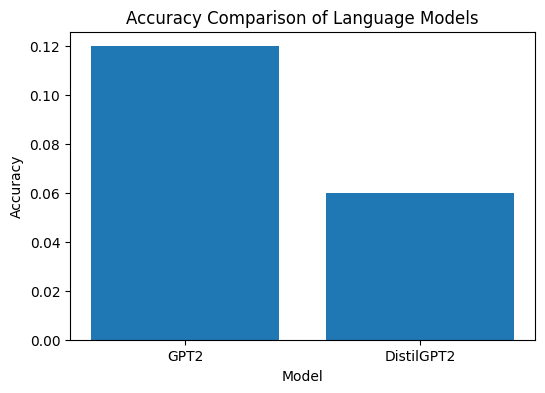

In [ ]:
models = ["GPT2","DistilGPT2"]
accuracy = [gpt2_accuracy, distil_accuracy]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)

plt.title("Accuracy Comparison of Language Models")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

## Additional Evaluation Metrics

To better understand the variability of model performance, we compute
the variance and standard deviation of the accuracy scores.

Variance measures how much the results vary across the dataset.
A lower variance indicates that the model performs more consistently
across different questions.

Standard deviation is the square root of variance and provides a more
interpretable measure of the spread of the results.

In [ ]:
gpt2_variance = np.var(gpt2_scores)
distil_variance = np.var(distil_scores)

gpt2_std = np.std(gpt2_scores)
distil_std = np.std(distil_scores)

print("GPT2 Variance:", gpt2_variance)
print("DistilGPT2 Variance:", distil_variance)

print("GPT2 Standard Deviation:", gpt2_std)
print("DistilGPT2 Standard Deviation:", distil_std)

GPT2 Variance: 0.1056
DistilGPT2 Variance: 0.0564
GPT2 Standard Deviation: 0.32496153618543844
DistilGPT2 Standard Deviation: 0.23748684174075835


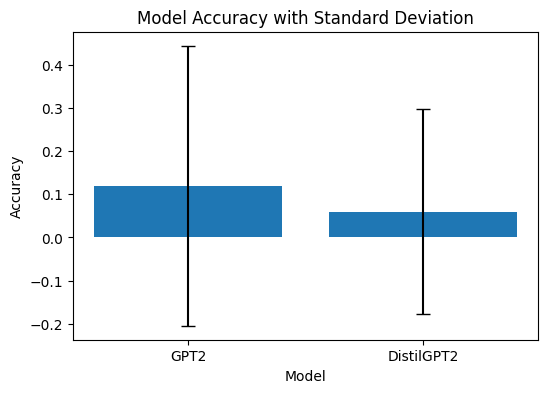

In [ ]:
models = ["GPT2","DistilGPT2"]
accuracy = [gpt2_accuracy, distil_accuracy]
errors = [gpt2_std, distil_std]

plt.figure(figsize=(6,4))

plt.bar(models, accuracy, yerr=errors, capsize=5)

plt.title("Model Accuracy with Standard Deviation")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

## Statistical Analysis

A single accuracy value does not fully describe the performance of a model.

Because the dataset is limited and the model generation process contains randomness, the measured accuracy may vary if the experiment is repeated.

To account for this uncertainty we apply statistical analysis techniques:

1. Bootstrap Confidence Intervals  
   Bootstrap sampling repeatedly resamples the results to estimate the distribution of the accuracy.

2. Hypothesis Testing  
   A statistical test is performed to determine whether the difference between the two models is statistically significant.

In [ ]:
def bootstrap(scores, n=1000):

    means = []

    for _ in range(n):
        sample = random.choices(scores, k=len(scores))
        means.append(np.mean(sample))

    return means

In [ ]:
gpt2_boot = bootstrap(gpt2_scores)
distil_boot = bootstrap(distil_scores)

print("GPT2 Confidence Interval:", np.percentile(gpt2_boot,[2.5,97.5]))
print("DistilGPT2 Confidence Interval:", np.percentile(distil_boot,[2.5,97.5]))

GPT2 Confidence Interval: [0.04 0.2 ]
DistilGPT2 Confidence Interval: [0.   0.14]


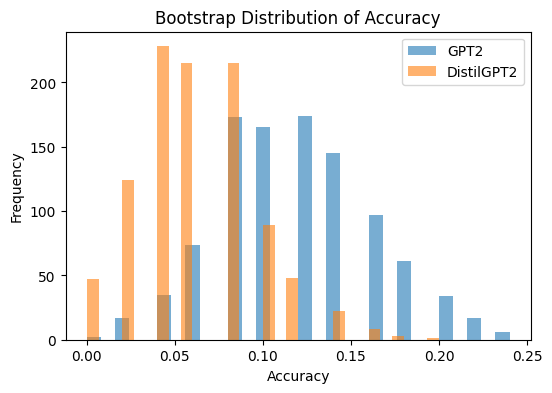

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(gpt2_boot, bins=30, alpha=0.6, label="GPT2")
plt.hist(distil_boot, bins=30, alpha=0.6, label="DistilGPT2")

plt.legend()
plt.title("Bootstrap Distribution of Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")

plt.show()

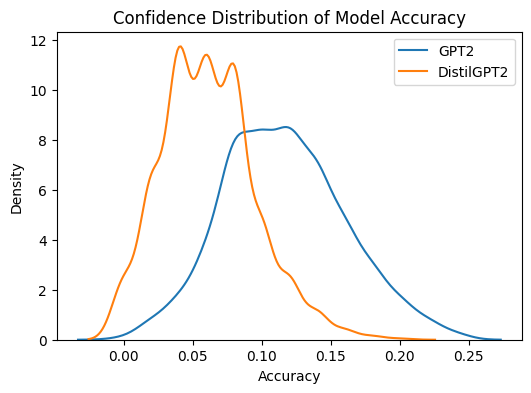

In [ ]:
plt.figure(figsize=(6,4))

sns.kdeplot(gpt2_boot, label="GPT2")
sns.kdeplot(distil_boot, label="DistilGPT2")

plt.legend()
plt.title("Confidence Distribution of Model Accuracy")
plt.xlabel("Accuracy")

plt.show()

In [ ]:
t_stat, p_value = ttest_ind(gpt2_boot, distil_boot)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 31.236740223495072
P-value: 9.103549570994658e-175


## Final Results Summary

To make the results easier to understand, the main evaluation metrics are summarized in a single table.

The table includes the following metrics:

Accuracy  
This represents the proportion of questions that each model answered correctly.

Variance  
Variance measures how much the results vary across the evaluation dataset. A higher variance indicates that the model’s performance is less consistent across different questions.

Standard Deviation  
Standard deviation provides another way to measure the spread of the results and helps indicate how stable the model’s performance is.

Confidence Interval  
The confidence interval shows the estimated range in which the true accuracy of the model is likely to fall. These values were estimated using bootstrap sampling.

P-value  
The p-value comes from the statistical hypothesis test comparing the two models. A p-value smaller than 0.05 indicates that the difference between the models is statistically significant.

Presenting these metrics together in a structured table makes it easier to compare the performance and stability of GPT-2 and DistilGPT2.

In [ ]:
import pandas as pd

# compute confidence interval values
gpt2_ci_lower, gpt2_ci_upper = np.percentile(gpt2_boot,[2.5,97.5])
distil_ci_lower, distil_ci_upper = np.percentile(distil_boot,[2.5,97.5])

# create results table
results_table = pd.DataFrame({
    "Model": ["GPT2","DistilGPT2"],
    "Accuracy": [gpt2_accuracy, distil_accuracy],
    "Variance": [gpt2_variance, distil_variance],
    "Std Deviation": [gpt2_std, distil_std],
    "Confidence Interval Lower": [gpt2_ci_lower, distil_ci_lower],
    "Confidence Interval Upper": [gpt2_ci_upper, distil_ci_upper],
})

results_table

,Model,Accuracy,Variance,Std Deviation,Confidence Interval Lower,Confidence Interval Upper
0,GPT2,0.12,0.1056,0.324962,0.04,0.20
1,DistilGPT2,0.06,0.0564,0.237487,0.00,0.14


In [ ]:
results_table["P-value"] = [p_value, p_value]

results_table

,Model,Accuracy,Variance,Std Deviation,Confidence Interval Lower,Confidence Interval Upper,P-value
0,GPT2,0.12,0.1056,0.324962,0.04,0.20,9.103550e-175
1,DistilGPT2,0.06,0.0564,0.237487,0.00,0.14,9.103550e-175


In [ ]:
results_table.style.format({
    "Accuracy":"{:.3f}",
    "Confidence Interval Lower":"{:.3f}",
    "Confidence Interval Upper":"{:.3f}",
    "P-value":"{:.4f}"
})

,Model,Accuracy,Variance,Std Deviation,Confidence Interval Lower,Confidence Interval Upper,P-value
0,GPT2,0.120,0.105600,0.324962,0.040,0.200,0.0000
1,DistilGPT2,0.060,0.056400,0.237487,0.000,0.140,0.0000


## Interpretation of the Results

The table above summarizes the evaluation results of GPT-2 and DistilGPT2 on the selected set of factual questions.

According to the results, GPT-2 achieved a higher accuracy (0.12) compared to DistilGPT2 (0.06). This indicates that the original GPT-2 model was able to generate correct answers more frequently than the distilled version.

The confidence intervals also show that the estimated accuracy range of GPT-2 is generally higher than that of DistilGPT2. In addition, the hypothesis test produced a very small p-value, indicating that the difference in performance between the two models is statistically significant.

These results suggest that the reduction in model size introduced by the distillation process leads to some loss of performance in this task. While DistilGPT2 is designed to be smaller and more efficient, the experiment shows that this compression can reduce factual response accuracy.

Overall, the experiment demonstrates how statistical evaluation methods such as confidence intervals and hypothesis testing can provide deeper insight into model performance beyond simple accuracy comparison.

## Conclusion

In this experiment, two language models, GPT-2 and DistilGPT2, were evaluated using a dataset of factual questions. The objective was to examine whether the smaller distilled model could achieve performance comparable to the original GPT-2 model.

The experimental results showed that GPT-2 achieved higher accuracy than DistilGPT2. Statistical analysis further confirmed that this difference is significant, as indicated by the very small p-value obtained from the hypothesis test.

These findings suggest that although DistilGPT2 provides a more compact and efficient version of the original model, the compression process can lead to a decrease in factual answering performance. This highlights the trade-off between model efficiency and predictive accuracy.

More broadly, the experiment illustrates the importance of using statistical evaluation methods when comparing machine learning models, as they help determine whether observed differences in performance are meaningful.